# Spotify Song Popularity Analysis

To analyze how different audio features are associated with song popularity on Spotify.

Author: Maria Horozova

# Introduction

Music streaming platforms generate large amounts of data describing the audio characteristics of songs. Spotify provides features such as danceability, energy, loudness, acousticness, tempo, and valence, which can be used to analyze patterns related to song popularity.

Understanding the relationship between audio features and popularity may provide insights into listener preferences and characteristics associated with commercially successful music.

This project utilizes two Spotify-related datasets:
- A large Spotify tracks dataset containing detailed audio features
- A dataset containing Top 50 Spotify songs from 2019

## Objective

The objective of this project is to analyze Spotify music datasets in order to identify relationships between audio characteristics and song popularity. Additionally, regression analysis will be used to examine the predictive relationship between audio features and popularity.

## Research Questions

- Do popular songs share similar audio characteristics?
- Which audio features are most strongly correlated with popularity?
- Can popularity be predicted using Spotify audio features?

## Hypothesis

It is hypothesized that songs with higher levels of danceability and energy are more likely to achieve greater popularity on Spotify.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
top = pd.read_csv("top50.csv", encoding='latin1')
tracks = pd.read_csv("dataset.csv")

## Dataset Overview

The first dataset contains approximately 114,000 Spotify tracks with audio features and popularity metrics. The dataset includes variables such as danceability, energy, loudness, speechiness, acousticness, instrumentalness, valence, and tempo.

The second dataset contains the Top 50 Spotify songs from 2019, including audio features and popularity scores for highly successful tracks.

In [3]:
tracks.shape

(114000, 21)

In [4]:
top.shape

(50, 14)

In [5]:
tracks.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

In [6]:
top.columns

Index(['Unnamed: 0', 'Track.Name', 'Artist.Name', 'Genre', 'Beats.Per.Minute',
       'Energy', 'Danceability', 'Loudness..dB..', 'Liveness', 'Valence.',
       'Length.', 'Acousticness..', 'Speechiness.', 'Popularity'],
      dtype='object')

## Removing Unnecessary Columns

In [7]:
tracks = tracks.drop(columns=['Unnamed: 0'])
top = top.drop(columns=['Unnamed: 0'])

## Standardizing Column Names

In [8]:
top = top.rename(columns={
    'Track.Name': 'track_name',
    'Artist.Name': 'artist_name',
    'Genre': 'genre',
    'Beats.Per.Minute': 'bpm',
    'Energy': 'energy',
    'Danceability': 'danceability',
    'Loudness..dB..': 'loudness',
    'Liveness': 'liveness',
    'Valence.': 'valence',
    'Length.': 'length',
    'Acousticness..': 'acousticness',
    'Speechiness.': 'speechiness',
    'Popularity': 'popularity'
})

In [9]:
top['danceability'] = top['danceability'] / 100
top['energy'] = top['energy'] / 100
top['acousticness'] = top['acousticness'] / 100
top['speechiness'] = top['speechiness'] / 100
top['valence'] = top['valence'] / 100
top['liveness'] = top['liveness'] / 100

## Duplicate Detection and Removal

In [10]:
tracks.duplicated().sum()

np.int64(450)

In [11]:
top.duplicated().sum()

np.int64(0)

In [12]:
tracks = tracks.drop_duplicates()

In [13]:
tracks.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [14]:
top.isnull().sum()

track_name      0
artist_name     0
genre           0
bpm             0
energy          0
danceability    0
loudness        0
liveness        0
valence         0
length          0
acousticness    0
speechiness     0
popularity      0
dtype: int64

In [15]:
tracks = tracks.dropna()

In [16]:
tracks.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [17]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   popularity        113549 non-null  int64  
 5   duration_ms       113549 non-null  int64  
 6   explicit          113549 non-null  bool   
 7   danceability      113549 non-null  float64
 8   energy            113549 non-null  float64
 9   key               113549 non-null  int64  
 10  loudness          113549 non-null  float64
 11  mode              113549 non-null  int64  
 12  speechiness       113549 non-null  float64
 13  acousticness      113549 non-null  float64
 14  instrumentalness  113549 non-null  float64
 15  liveness          113549 non-null  float64
 16  valence           113549 

In [18]:
top.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   track_name    50 non-null     object 
 1   artist_name   50 non-null     object 
 2   genre         50 non-null     object 
 3   bpm           50 non-null     int64  
 4   energy        50 non-null     float64
 5   danceability  50 non-null     float64
 6   loudness      50 non-null     int64  
 7   liveness      50 non-null     float64
 8   valence       50 non-null     float64
 9   length        50 non-null     int64  
 10  acousticness  50 non-null     float64
 11  speechiness   50 non-null     float64
 12  popularity    50 non-null     int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 5.2+ KB


In [19]:
print(tracks.shape)
print(top.shape)

(113549, 20)
(50, 13)


After cleaning, the Spotify tracks dataset contained approximately 113,500 records, while the Top 50 dataset retained all 50 records.

## Data Cleaning

The Spotify tracks dataset contained a very small number of missing values in the artist, album name, and track name columns. Because the number of affected records was minimal, these rows were removed to ensure consistency during statistical analysis and regression modeling.

Potential outliers may exist in variables such as tempo and duration. However, outlier removal was not performed in order to preserve the original distribution of the datasets.

Approximately 450 duplicate records were identified and removed from the Spotify tracks dataset in order to avoid biased statistical results.

Several variables in the Top 50 dataset were originally measured on a 0–100 scale, whereas the larger Spotify tracks dataset used a 0–1 scale. These variables were normalized to ensure consistency and comparability between datasets.

## Final Cleaned Datasets

In [20]:
tracks.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [21]:
top.head()

,track_name,artist_name,genre,bpm,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity
0,Señorita,Shawn Mendes,canadian pop,117,0.55,0.76,-6,0.08,0.75,191,0.04,0.03,79
1,China,Anuel AA,reggaeton flow,105,0.81,0.79,-4,0.08,0.61,302,0.08,0.09,92
2,boyfriend (with Social House),Ariana Grande,dance pop,190,0.80,0.40,-4,0.16,0.70,186,0.12,0.46,85
3,Beautiful People (feat. Khalid),Ed Sheeran,pop,93,0.65,0.64,-8,0.08,0.55,198,0.12,0.19,86
4,Goodbyes (Feat. Young Thug),Post Malone,dfw rap,150,0.65,0.58,-4,0.11,0.18,175,0.45,0.07,94


## Descriptive Statistics Analysis

The descriptive statistics provide an overview of the central tendencies and distributions of the audio features and popularity variables across both Spotify datasets.

The analysis focuses on identifying general patterns, variability, and differences between the broader Spotify tracks dataset and the Top 50 Spotify songs dataset.

In [22]:
tracks.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113549.000000,1.135490e+05,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000,113549.000000
mean,33.324433,2.280814e+05,0.567031,0.642091,5.309452,-8.243408,0.637866,0.084674,0.314064,0.155703,0.213613,0.474205,122.175745,3.904218
std,22.283855,1.064131e+05,0.173409,0.251053,3.560147,5.011422,0.480620,0.105762,0.331906,0.309217,0.190462,0.259204,29.972954,0.432117
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.741840e+05,0.456000,0.473000,2.000000,-9.998000,0.000000,0.035900,0.016800,0.000000,0.098000,0.260000,99.296000,4.000000
50%,35.000000,2.130000e+05,0.580000,0.685000,5.000000,-6.997000,1.000000,0.048900,0.168000,0.000041,0.132000,0.464000,122.020000,4.000000
75%,50.000000,2.615880e+05,0.695000,0.854000,8.000000,-5.001000,1.000000,0.084500,0.596000,0.048700,0.273000,0.683000,140.074000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [23]:
top.describe()

,bpm,energy,danceability,loudness,liveness,valence,length,acousticness,speechiness,popularity
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000
mean,120.060000,0.640600,0.713800,-5.660000,0.146600,0.54600,200.960000,0.221600,0.124800,87.500000
std,30.898392,0.142319,0.119299,2.056448,0.111183,0.22336,39.143879,0.189956,0.111616,4.491489
min,85.000000,0.320000,0.290000,-11.000000,0.050000,0.10000,115.000000,0.010000,0.030000,70.000000
25%,96.000000,0.552500,0.670000,-6.750000,0.080000,0.38250,176.750000,0.082500,0.050000,86.000000
50%,104.500000,0.665000,0.735000,-6.000000,0.110000,0.55500,198.000000,0.150000,0.070000,88.000000
75%,137.500000,0.747500,0.797500,-4.000000,0.157500,0.69500,217.500000,0.337500,0.150000,90.750000
max,190.000000,0.880000,0.900000,-2.000000,0.580000,0.95000,309.000000,0.750000,0.460000,95.000000


In the larger Spotify tracks dataset, the average popularity score is approximately 33. The popularity distribution indicates that a large proportion of songs have relatively low popularity scores, while highly popular songs are comparatively uncommon.

The average danceability score is approximately 0.57, indicating that many Spotify tracks are moderately danceable. The average energy score is also moderately high (mean ≈ 0.64), suggesting that many tracks contain relatively energetic audio characteristics.

The relatively large standard deviation of popularity scores indicates substantial variability in song popularity across the Spotify tracks dataset.

The Top 50 Spotify songs dataset shows substantially higher popularity values, with an average popularity score of approximately 87. This suggests that the dataset primarily contains highly successful and widely streamed songs.

Additionally, the Top 50 dataset exhibits noticeably higher average danceability values compared to the broader Spotify dataset. However, average energy levels are relatively similar across both datasets.

These findings suggest that highly popular songs may share certain audio characteristics, particularly higher danceability.

## Popularity Distribution

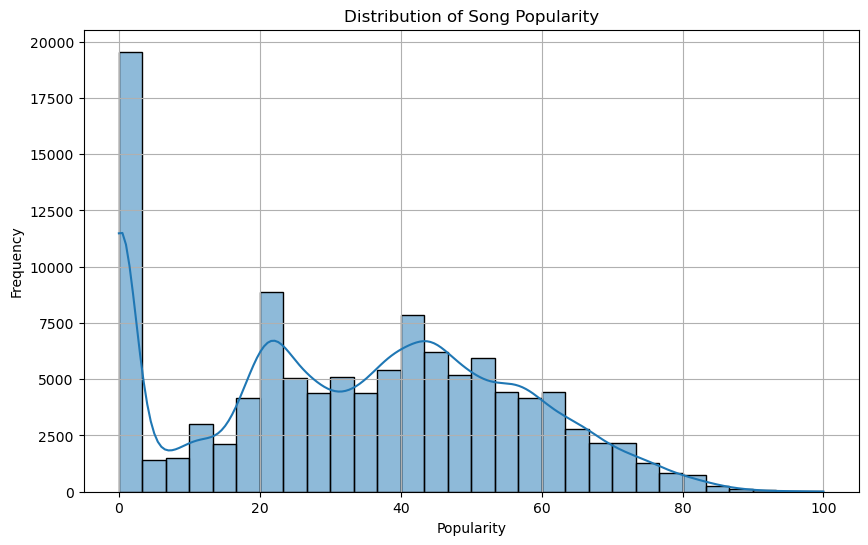

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(tracks['popularity'], bins=30, kde=True)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Frequency")

plt.grid()

plt.show()

The histogram reveals a strong concentration of songs with very low popularity scores, indicating that a substantial portion of Spotify tracks receive limited listener attention.

Most songs are concentrated in the low-to-medium popularity range, while highly popular songs are relatively uncommon.

The distribution appears right-skewed, with a long tail extending toward higher popularity values.

Because the popularity variable exhibits a skewed distribution, subsequent correlation and regression analyses should be interpreted cautiously.

## Danceability Distribution

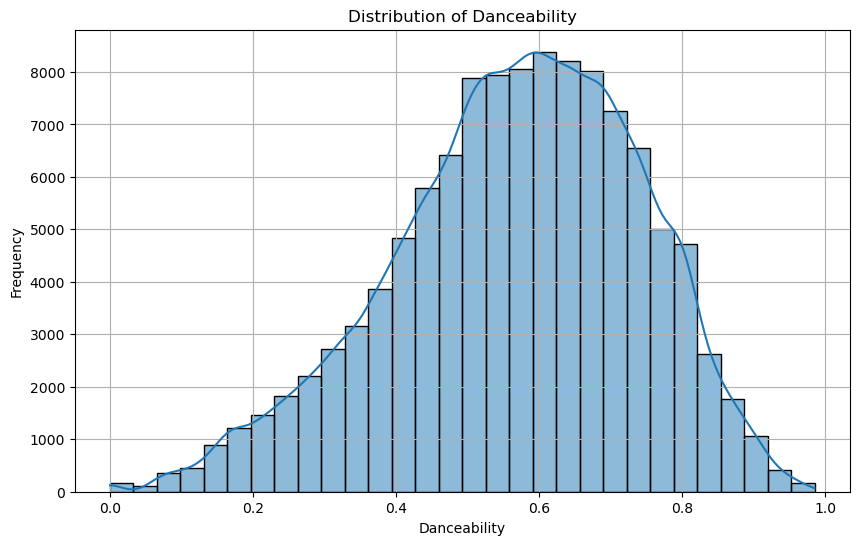

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(tracks['danceability'], bins=30, kde=True)

plt.title("Distribution of Danceability")
plt.xlabel("Danceability")
plt.ylabel("Frequency")

plt.grid()

plt.show()

The histogram shows the distribution of danceability values across Spotify tracks.

Most songs are concentrated in the moderate-to-high danceability range, particularly between 0.5 and 0.7.

The distribution appears approximately unimodal, with relatively few songs exhibiting extremely low or extremely high danceability values.

The relatively moderate standard deviation indicates that danceability values are reasonably concentrated around the mean.

## Energy Distribution

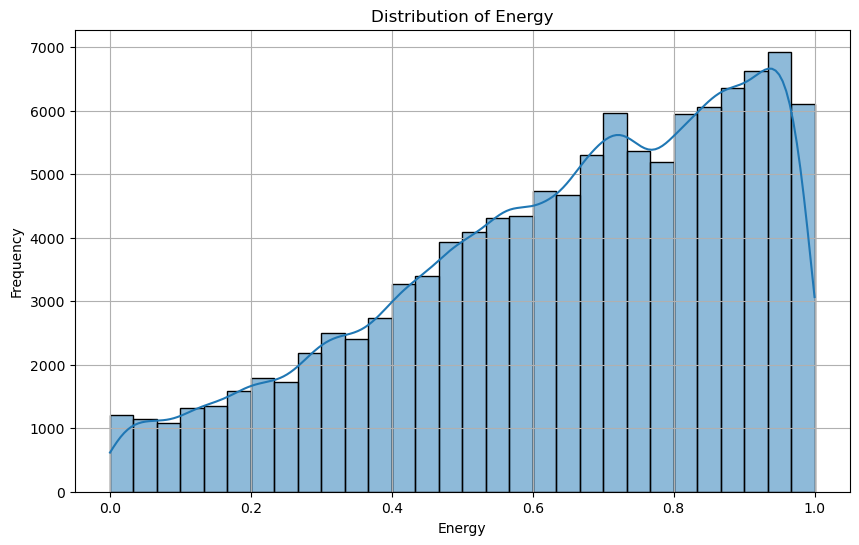

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(tracks['energy'], bins=30, kde=True)

plt.title("Distribution of Energy")
plt.xlabel("Energy")
plt.ylabel("Frequency")

plt.grid()

plt.show()

The energy distribution is concentrated toward moderate-to-high values, indicating that many Spotify tracks contain relatively energetic audio characteristics.

Extremely low-energy songs appear less common within the dataset.

The distribution suggests that energetic music characteristics are prevalent across Spotify tracks.

## Danceability Comparison Between Datasets

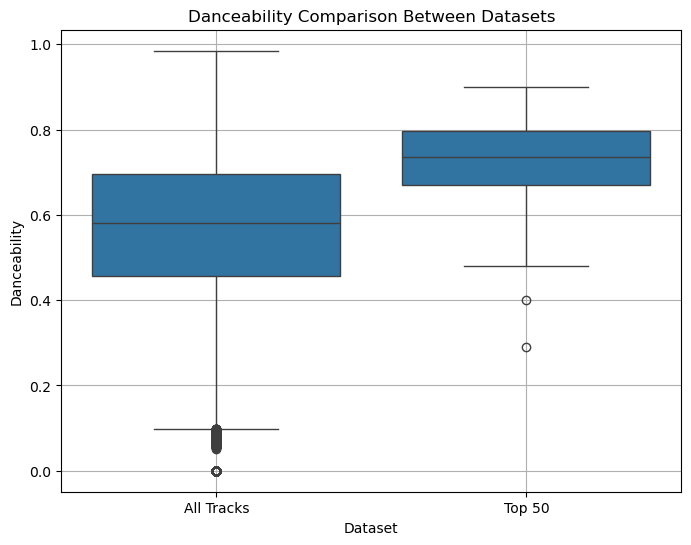

In [27]:
comparison_df = pd.DataFrame({
    'Danceability': pd.concat([
        tracks['danceability'],
        top['danceability']
    ], ignore_index=True),
    
    'Dataset': (
        ['All Tracks'] * len(tracks) +
        ['Top 50'] * len(top)
    )
})

plt.figure(figsize=(8,6))

sns.boxplot(
    data=comparison_df,
    x='Dataset',
    y='Danceability'
)

plt.title('Danceability Comparison Between Datasets')
plt.ylabel('Danceability')

plt.grid()

plt.show()

The boxplot indicates that Top 50 Spotify songs generally exhibit higher danceability values compared to the broader Spotify tracks dataset.

The median danceability of the Top 50 songs is noticeably higher, suggesting that highly popular songs may share stronger dance-oriented characteristics.

While descriptive statistics provide useful insights into the distributions and characteristics of Spotify tracks, they do not directly measure relationships between variables.

To further investigate the associations between audio features and popularity, correlation analysis is performed in the following section.

# Correlation Analysis

Correlation analysis was performed to examine the relationships between Spotify audio features and song popularity.

Pearson correlation coefficients were calculated to measure the strength and direction of linear relationships between variables.

Understanding these relationships may help identify which musical characteristics are associated with song popularity.

In [28]:
corr_data = tracks[[
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]]

In [29]:
correlation_matrix = corr_data.corr()

correlation_matrix

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,0.034407,-0.002447,0.047368,-0.045463,-0.022356,-0.094718,-0.005668,-0.041097,0.012187
danceability,0.034407,1.000000,0.131694,0.256559,0.108236,-0.169181,-0.183974,-0.131651,0.476755,-0.051517
energy,-0.002447,0.131694,1.000000,0.760624,0.141976,-0.732747,-0.179967,0.184810,0.258451,0.247361
loudness,0.047368,0.256559,0.760624,1.000000,0.060088,-0.588111,-0.432109,0.076792,0.279428,0.212181
speechiness,-0.045463,0.108236,0.141976,0.060088,1.000000,-0.001378,-0.089214,0.205092,0.036393,0.017167
acousticness,-0.022356,-0.169181,-0.732747,-0.588111,-0.001378,1.000000,0.102134,-0.020313,-0.106240,-0.207620
instrumentalness,-0.094718,-0.183974,-0.179967,-0.432109,-0.089214,0.102134,1.000000,-0.079847,-0.324314,-0.049939
liveness,-0.005668,-0.131651,0.184810,0.076792,0.205092,-0.020313,-0.079847,1.000000,0.019339,0.000547
valence,-0.041097,0.476755,0.258451,0.279428,0.036393,-0.106240,-0.324314,0.019339,1.000000,0.077640
tempo,0.012187,-0.051517,0.247361,0.212181,0.017167,-0.207620,-0.049939,0.000547,0.077640,1.000000


## Correlation Interpretation

Correlation coefficients range from -1 to 1.

Positive values indicate that variables tend to increase together, while negative values indicate inverse relationships.

Correlation coefficients closer to -1 or 1 indicate stronger linear relationships, whereas values near zero indicate weak or negligible linear associations.

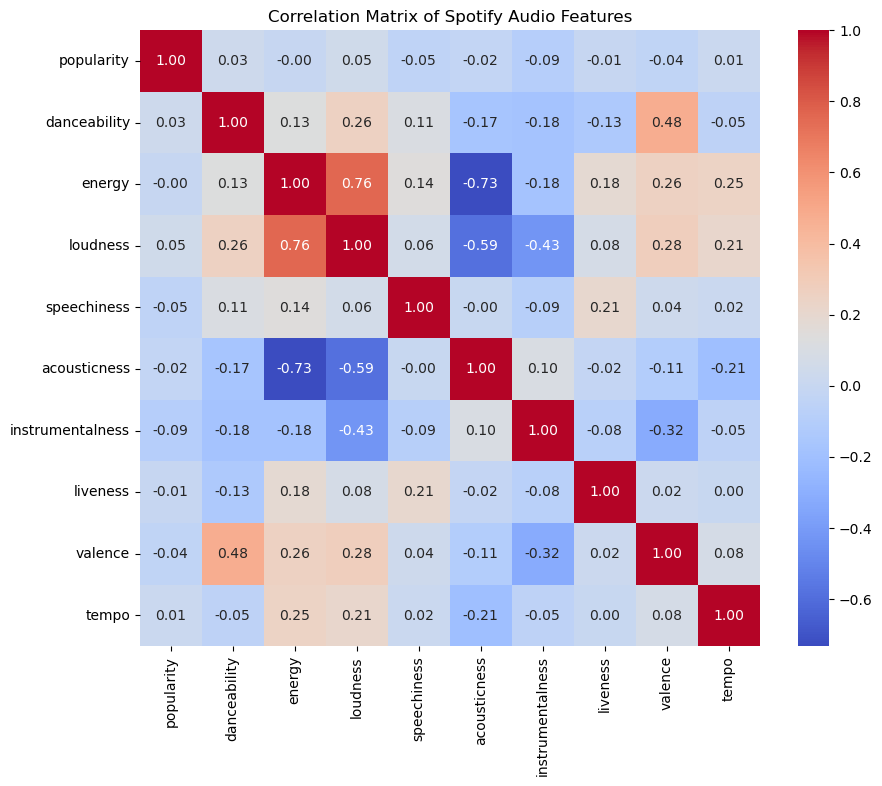

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix of Spotify Audio Features")

plt.show()

## Correlation Analysis

The correlation matrix reveals several relationships between Spotify audio features and popularity.

Popularity exhibits extremely weak correlations with most audio features, including danceability and energy.

These results suggest that individual audio characteristics alone do not strongly explain song popularity on Spotify.

A strong positive correlation is observed between energy and loudness, indicating that more energetic songs are generally louder.

Acousticness demonstrates a strong negative correlation with energy and a moderate negative correlation with loudness, suggesting that acoustic tracks are typically less energetic and quieter.

Most correlations appear relatively weak to moderate, indicating that no single audio feature strongly determines song popularity.

## Feature Relationships

Several audio features exhibit relatively strong correlations with one another.

For example, energy and loudness show a strong positive correlation, while energy and acousticness demonstrate a strong negative correlation.

These relationships suggest potential multicollinearity between certain predictors, which should be considered during regression analysis.

Although correlation analysis identifies statistical associations between variables, it does not establish causal relationships.

For example, a positive correlation between danceability and popularity does not imply that higher danceability directly causes songs to become more popular.

In [31]:
correlation_matrix['popularity'].sort_values(ascending=False)

popularity          1.000000
loudness            0.047368
danceability        0.034407
tempo               0.012187
energy             -0.002447
liveness           -0.005668
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

The strongest positive correlations with popularity are observed for danceability and energy, although the relationships remain relatively weak overall.

## Danceability and Popularity

This section examines the relationship between danceability and song popularity.

Danceability measures how suitable a track is for dancing based on rhythm, beat stability, and tempo.

The analysis explores whether highly danceable songs tend to achieve greater popularity on Spotify.

In [32]:
sample_tracks = tracks.sample(5000, random_state=42)

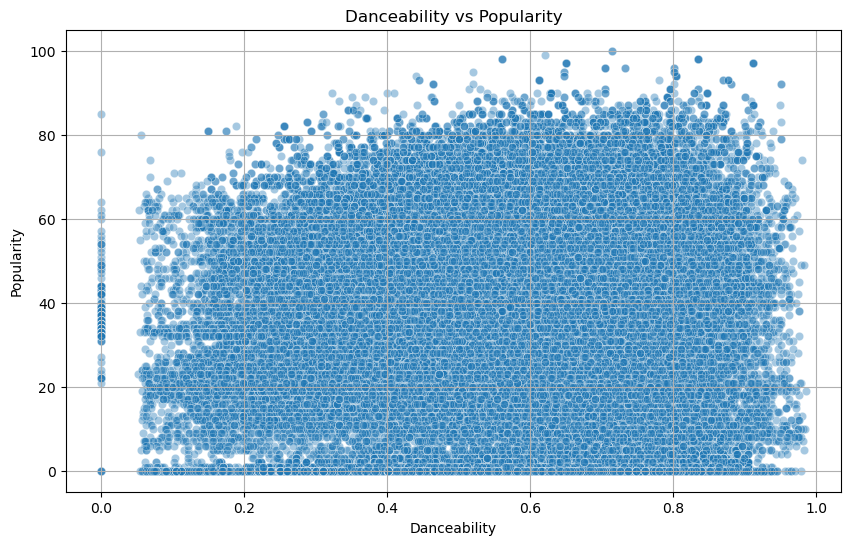

In [33]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='danceability',
    y='popularity',
    data=tracks,
    alpha=0.4
)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.grid()

plt.show()

## Danceability vs Popularity Analysis

The scatterplot shows substantial variability in popularity across all danceability levels, indicating that danceability alone is not a strong predictor of popularity.

Although moderately danceable songs appear somewhat common among popular tracks, the overall relationship remains weak.

## Energy and Popularity

This section examines the relationship between song energy and popularity.

Energy describes the intensity and activity level of a track. Highly energetic songs are typically louder, faster, and more dynamic.

The goal is to determine whether more energetic songs tend to achieve higher popularity on Spotify.

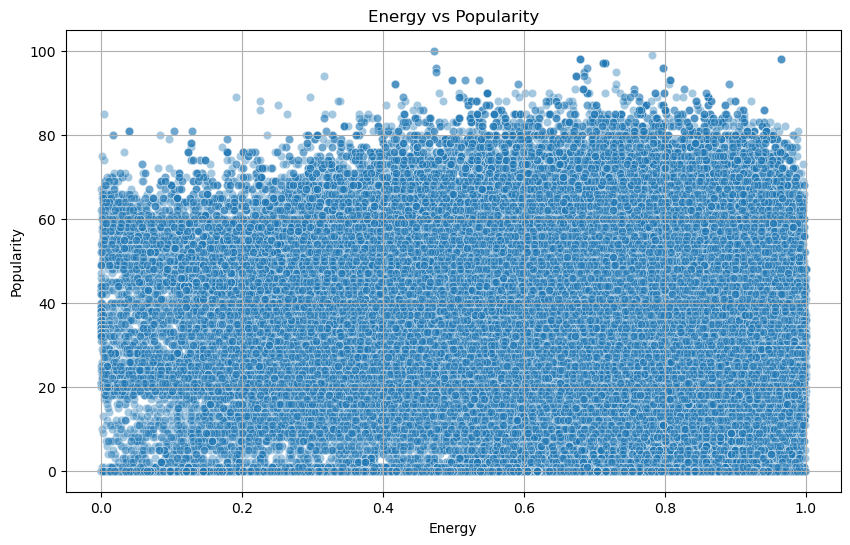

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='energy',
    y='popularity',
    data=tracks,
    alpha=0.4
)

plt.title("Energy vs Popularity")
plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.grid()

plt.show()

## Energy vs Popularity Analysis

The scatterplot shows no clear linear relationship between energy and popularity.

Popularity values remain widely distributed across all energy levels, suggesting that energy alone is not strongly associated with popularity.

## Genre Analysis

This section examines how popularity varies across different music genres.

Genre analysis helps identify whether certain genres tend to achieve higher average popularity levels on Spotify.

The analysis focuses on comparing average popularity scores between genres and identifying the most successful genres in the dataset.

In [35]:
genre_counts = tracks['track_genre'].value_counts()

valid_genres = genre_counts[genre_counts > 100].index

filtered_tracks = tracks[
    tracks['track_genre'].isin(valid_genres)
]

In [36]:
genre_popularity = filtered_tracks.groupby(
    'track_genre'
)['popularity'].mean()

top_genres = genre_popularity.sort_values(
    ascending=False
)

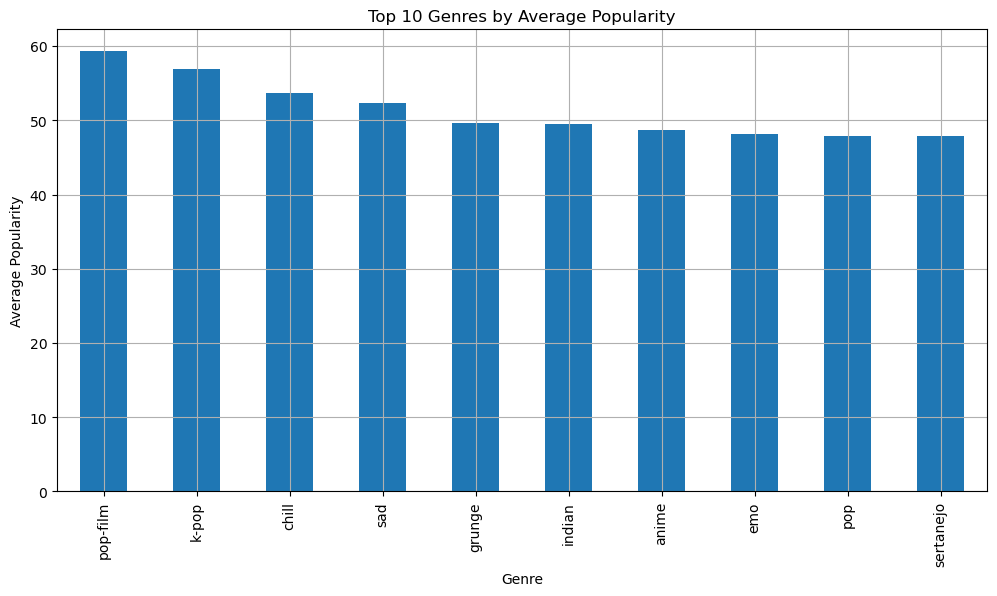

In [37]:
plt.figure(figsize=(12,6))

top_genres.head(10).plot(kind='bar')

plt.title('Top 10 Genres by Average Popularity')

plt.xlabel('Genre')
plt.ylabel('Average Popularity')

plt.grid()

plt.show()

## Genre Popularity Analysis

The grouped analysis reveals differences in average popularity between music genres.

Genres such as pop-film, k-pop, and pop exhibit some of the highest average popularity values within the dataset.

These findings suggest that certain genres in the dataset tend to achieve higher average popularity scores than others.

While correlation analysis provides insights into relationships between variables, it does not directly measure predictive performance.

To further investigate whether Spotify audio features can predict song popularity, regression analysis is performed in the following section.

## Comparison Between General Spotify Tracks and Top Songs

This section compares selected audio characteristics between the broader Spotify tracks dataset and the Top 50 Spotify songs dataset.

In [38]:
comparison = pd.DataFrame({
    'All Tracks': [
        tracks['danceability'].mean(),
        tracks['energy'].mean(),
        tracks['valence'].mean()
    ],
    
    'Top 50 Songs': [
        top['danceability'].mean(),
        top['energy'].mean(),
        top['valence'].mean()
    ]
},

index=[
    'Danceability',
    'Energy',
    'Valence'
])

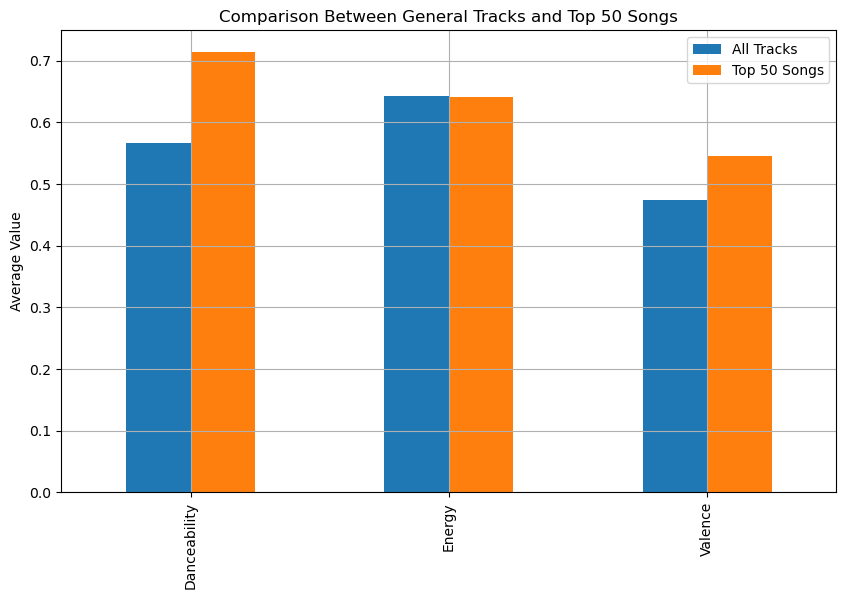

In [39]:
comparison.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Comparison Between General Tracks and Top 50 Songs")

plt.ylabel("Average Value")

plt.grid()

plt.show()

The comparison indicates that Top 50 Spotify songs generally exhibit higher danceability values than the broader Spotify tracks dataset.

Energy values appear relatively similar across both datasets, while valence values show moderate differences.

These findings support the earlier descriptive statistics and hypothesis testing results suggesting that highly popular songs tend to exhibit higher danceability levels.

However, the correlation and regression analyses indicate that danceability alone is insufficient to strongly predict popularity.

## Regression Analysis

Regression analysis was performed to investigate whether Spotify audio features can predict song popularity.

A multiple linear regression model was used to examine the relationship between several audio characteristics and popularity scores.

In [40]:
features = tracks[[
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]]

target = tracks['popularity']

## Train-Test Split

The dataset was divided into training and testing subsets in order to evaluate model performance on unseen data.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Feature scaling was applied to standardize the predictor variables before regression modeling.

Standardization ensures that variables measured on different scales contribute more consistently to the regression model.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred = model.predict(X_test_scaled)

## Model Evaluation

The regression model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

MAE measures the average prediction error, while RMSE places greater emphasis on larger prediction errors.

R² indicates the proportion of popularity variability explained by the model.

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 18.493302867976944
RMSE: 22.123700642676624
R²: 0.024233057215020226


## Model Performance Interpretation

The regression model produced relatively low predictive performance.

The MAE value indicates that the model's predictions differ from actual popularity scores by approximately 18 popularity points on average.

Similarly, the RMSE value suggests that larger prediction errors are also present within the model.

The R² value of approximately 0.024 indicates that the regression model explains only a very small proportion of the variability in Spotify popularity scores.

These findings suggest that Spotify audio features alone are insufficient for accurately predicting song popularity.

Popularity is likely influenced by many additional factors beyond audio characteristics, including artist reputation, marketing, playlist placement, and social trends.

## Regression Coefficients
The regression coefficients indicate the direction and relative influence of each audio feature within the regression model.

Positive coefficients suggest that increases in a feature are associated with slightly higher predicted popularity values, whereas negative coefficients indicate inverse relationships.

In [46]:
coefficients = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
0,danceability,1.544458
2,loudness,0.537506
8,tempo,0.393011
6,liveness,0.237120
4,acousticness,-0.326315
1,energy,-0.685998
3,speechiness,-1.274244
7,valence,-2.457782
5,instrumentalness,-2.560760


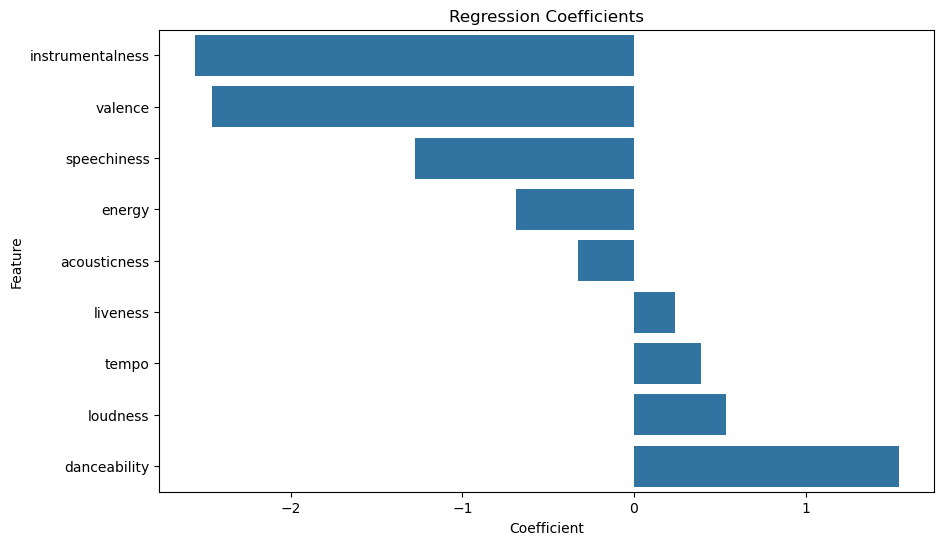

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients.sort_values(by='Coefficient')
)

plt.title('Regression Coefficients')

plt.show()

## Regression Analysis Conclusion

The regression analysis demonstrates that Spotify audio features alone have limited predictive power for song popularity.

Although certain features exhibit weak associations with popularity, the overall model performance suggests that popularity is influenced by many external and non-audio factors.

Therefore, audio characteristics alone are insufficient for accurately predicting Spotify popularity.

## Hypothesis Testing

A statistical hypothesis test was performed to examine whether Top 50 Spotify songs exhibit different danceability levels compared to the broader Spotify tracks dataset.

Null Hypothesis:
There is no significant difference in danceability between Spotify tracks and Top 50 songs.

Alternative Hypothesis:
Top 50 songs have significantly higher danceability values.

In [48]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    tracks['danceability'],
    top['danceability'],
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -8.695217378930602
P-value: 1.6599075018761696e-11


## T-test Interpretation

The p-value measures the probability of observing the difference in danceability values under the assumption that the null hypothesis is true.

If the p-value is smaller than the significance level (α = 0.05), the null hypothesis is rejected.

Since the p-value is substantially smaller than the significance level (α = 0.05), the null hypothesis is rejected.

This result suggests that Top 50 Spotify songs exhibit significantly higher danceability values compared to the broader Spotify tracks dataset.

The negative t-statistic reflects the higher average danceability observed in the Top 50 dataset relative to the broader Spotify tracks dataset.

The hypothesis test was conducted using a 95% confidence level (α = 0.05).

## Residual Analysis

Residual analysis was performed to evaluate how well the regression model fits the Spotify popularity data.

Residuals represent the differences between the actual popularity values and the popularity values predicted by the regression model.

Analyzing residuals helps identify unexplained variation, potential prediction errors, and limitations of the regression model.

In [49]:
predictions = model.predict(X_test_scaled)

residuals = y_test - predictions

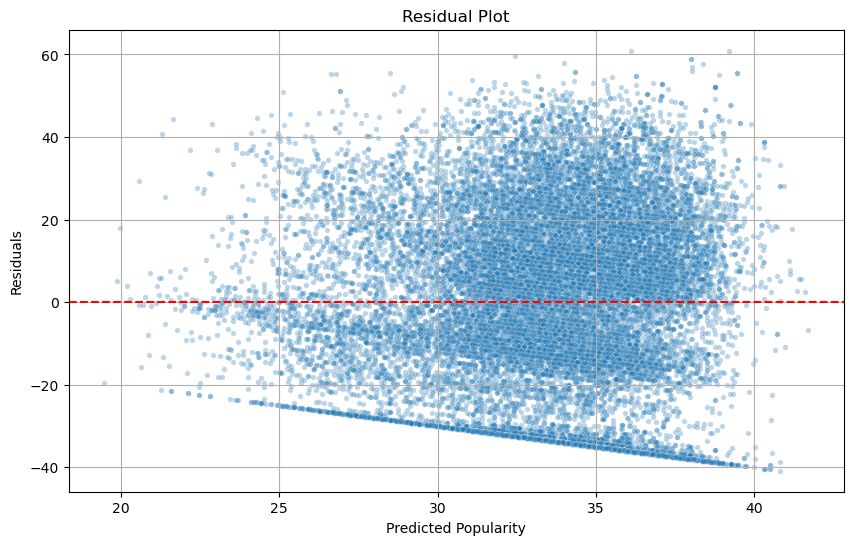

In [50]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=predictions,
    y=residuals,
    alpha=0.3,
    s=15
)

plt.axhline(0, color='red', linestyle='--')

plt.title("Residual Plot")
plt.xlabel("Predicted Popularity")
plt.ylabel("Residuals")

plt.grid()

plt.show()

The residual plot illustrates the differences between actual popularity values and the popularity values predicted by the regression model.

The residuals display substantial variability across the predicted popularity values, indicating that the regression model does not strongly capture Spotify popularity patterns.

The wide spread of residuals around zero suggests that the model leaves a considerable portion of popularity variation unexplained.

Although no perfectly clear systematic pattern is visible, the residual spread suggests that important explanatory variables may be missing from the model.

These findings further support the conclusion that Spotify popularity is influenced by many additional factors beyond the selected audio features, including artist reputation, marketing, recommendation algorithms, and social trends.